<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/W04_Part_2_23521013_Arief_Purnama_Muharram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-4 Assignment: weather-stations.csv
___
Name: Arief Purnama Muharram<br>
Student number: 23521013

Task:<br>
Cluster the weather based on its mean, maximum, and minimum temperature.

In [ ]:
# Install the required modules.

!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install kneed

In [ ]:
# Connect the Google Drive.

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Pre-processing
___

In [ ]:
# Import the data.
# data: weather-stations.csv

import pandas as pd

_ = pd.read_csv('/content/drive/MyDrive/weather-stations.csv')

_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1341 entries, 0 to 1340
Data columns (total 25 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Stn_Name  1341 non-null   object 
 1   Lat       1341 non-null   float64
 2   Long      1341 non-null   float64
 3   Prov      1341 non-null   object 
 4   Tm        1256 non-null   float64
 5   DwTm      1256 non-null   float64
 6   D         357 non-null    float64
 7   Tx        1260 non-null   float64
 8   DwTx      1260 non-null   float64
 9   Tn        1260 non-null   float64
 10  DwTn      1260 non-null   float64
 11  S         586 non-null    float64
 12  DwS       586 non-null    float64
 13  S%N       198 non-null    float64
 14  P         1227 non-null   float64
 15  DwP       1227 non-null   float64
 16  P%N       209 non-null    float64
 17  S_G       798 non-null    float64
 18  Pd        1227 non-null   float64
 19  BS        0 non-null      float64
 20  DwBS      0 non-null      floa

In [ ]:
# Only select the required attribute based on the given task.

df = pd.DataFrame()

# Mean temperature.
df['Tm'] = _['Tm']

# Lowest monthly minimum temperature.
df['Tn'] = _['Tn']

# Maximum monthly maximum temperature.
df['Tx'] = _['Tx']

In [ ]:
# Check if there is any null value.

df.isnull().any()

Tm    True
Tn    True
Tx    True
dtype: bool

In [ ]:
# Drop any null value.

df.dropna(how='any', inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1255 entries, 0 to 1340
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Tm      1255 non-null   float64
 1   Tn      1255 non-null   float64
 2   Tx      1255 non-null   float64
dtypes: float64(3)
memory usage: 39.2 KB


In [ ]:
# Statistical description of the data.

df.describe()

,Tm,Tn,Tx
count,1255.000000,1255.000000,1255.000000
mean,-12.056653,-26.310438,2.633785
std,10.418567,12.591393,8.852441
min,-38.200000,-49.700000,-29.800000
25%,-18.500000,-35.450000,-3.500000
50%,-13.800000,-29.100000,2.500000
75%,-5.600000,-21.700000,10.000000
max,9.600000,5.300000,22.000000


In [ ]:
# Normalize the data.

from sklearn.preprocessing import normalize

df_scaled = normalize(df)

## Density-based Method (DBSCAN)
___
References:<br>
<ul>
<li>Tutorial for DBSCAN clustering in Python SKlearn, <i>Kumar V</i>, available from:
https://machinelearningknowledge.ai/tutorial-for-dbscan-clustering-in-python-sklearn/</li>
<li>DBSCAN parameter estimation using Python, <i>Mullin T</i>, Medium, available from:
https://medium.com/@tarammullin/dbscan-parameter-estimation-ff8330e3a3bd</li>
</ul>

In [ ]:
# Minimum samples ("MinPts")
# There is no automatic way to determine the MinPts value for DBSCAN.
# If the data has more than 2 dimensions, choose MinPts = 2 * dim,
# where dim = the dimension of the dataset (Sander et al., 1998). 
#
# Therefore, the MinPts of this dataset is 6 (2*3).

min_pts = 6

Epsilon value: 0.018027193677777432


<Figure size 360x360 with 0 Axes>

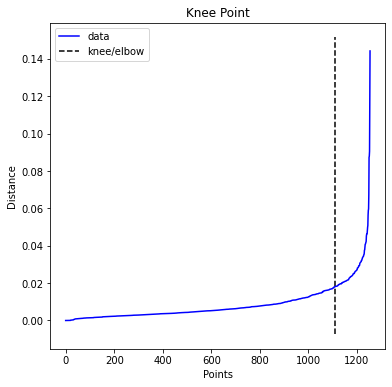

In [ ]:
# Determine the Epsilon value.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors 
from kneed import KneeLocator

data = df_scaled

nearest_neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors = nearest_neighbors.fit(data)

distances, indices = neighbors.kneighbors(data) 

distances = np.sort(distances, axis=0)
distances = distances[:,1]

i = np.arange(len(distances))
knee = KneeLocator(i, distances, S=1, curve='convex', direction='increasing', interp_method='polynomial')

fig = plt.figure(figsize=(5, 5))
knee.plot_knee()
plt.xlabel("Points")
plt.ylabel("Distance")

epsilon = distances[knee.knee]
print('Epsilon value:', epsilon)

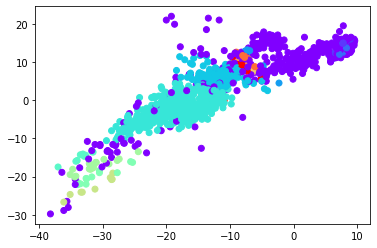

In [ ]:
# DBSCAN model.

from sklearn.cluster import DBSCAN

model = DBSCAN(eps=epsilon, min_samples=min_pts)

model.fit_predict(data)

plt.scatter(df['Tm'], df['Tx'], c=model.labels_, cmap='rainbow')

In [ ]:
# Silhouette score evaluation.

from sklearn.metrics import silhouette_score

score = silhouette_score(df_scaled, model.fit_predict(df_scaled))

print("The Silhouette score is", score)

The Silhouette score is -0.049349877207598015
